# ¿Que Habilidades Brindan Mejores Oportunidades de Trabajo?

## Proposito del Notebook
- Encontrar las 8 Habilidades más solicitadas y la mediana de su salario para los 3 trabajos con mas demanda.
- Separar las Habilidades por Categorías.
- Mostrar todo en un gráfico de dispersión.

## Cargar librerias y el archivo

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from rutas import ruta_archivo_limpio
import seaborn as sns 

df = pd.read_parquet(ruta_archivo_limpio())
df_trabajar = df.copy()
df_trabajar

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'programming': ['py..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'analyst_tools': None, 'programming': ['pytho..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'analyst_tools': None, 'programming': ['bash'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'analyst_tools': None, 'programming': ['bash'..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel'], 'pr..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'analyst_tools': None, 'programming': ['pytho..."


## Creación del Grafico

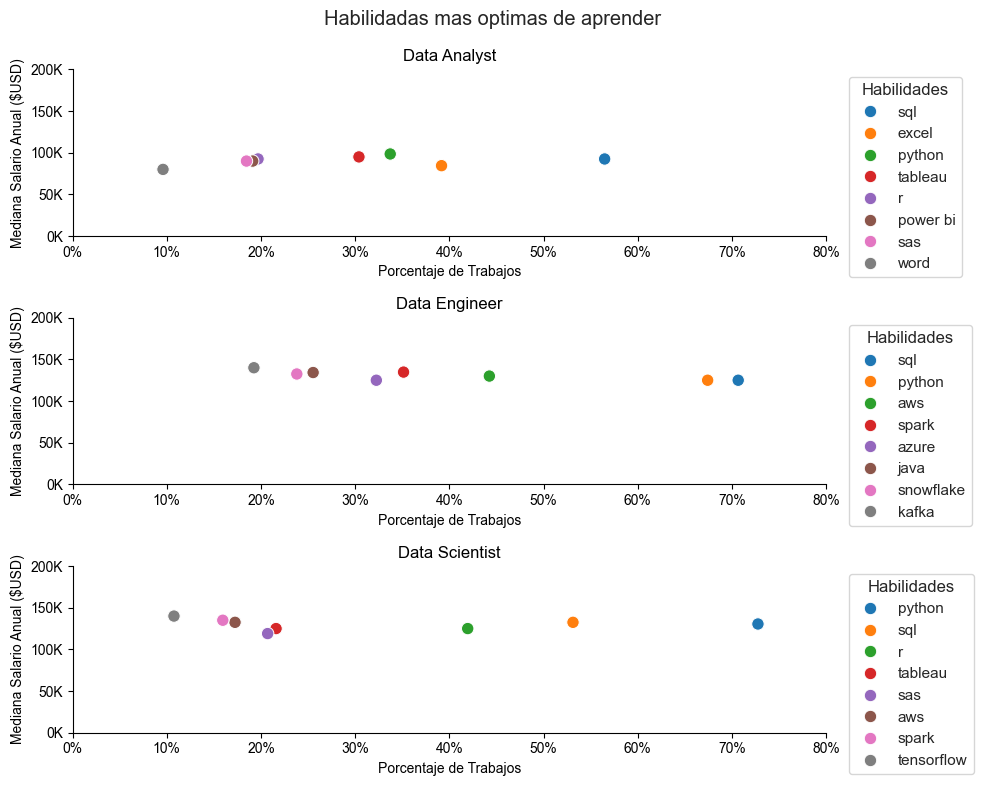

In [2]:
# Selección de los 3 puestos de trabajos más solicitados 
top_3_trabajos = df_trabajar.job_title_short.value_counts().head(3).index.tolist()

fig,ax = plt.subplots(3,1,figsize=(10,8))

sns.set_theme(style='whitegrid')
for i, rol in enumerate(top_3_trabajos):
    df_filtrar = df_trabajar[(df_trabajar.job_title_short==rol) & (df_trabajar.salary_year_avg.notna())]
    total_registros = len(df_filtrar)
    
    # Expandimos por habilidades 
    g_dispersion = df_filtrar.explode('job_skills')
    
    g_dispersion = (
        g_dispersion.groupby('job_skills')
        .agg(
        cantidad_ofertas = ('job_skills','count'),
        mediana_salario = ('salary_year_avg','median')
        )
        .sort_values(by='cantidad_ofertas',ascending=False)
        .head(8)
    )
    
    g_dispersion['porcentaje'] = g_dispersion.cantidad_ofertas.div(total_registros/100)
    
    sns.scatterplot(
        data=g_dispersion,
        x='porcentaje',
        y='mediana_salario',
        hue=g_dispersion.index,
        s=80,
        ax=ax[i],
        palette='tab10'
    )
    
    ax[i].set_title(rol)
    ax[i].set_xlabel('Porcentaje de Trabajos')
    ax[i].set_ylabel('Mediana Salario Anual ($USD)')
    ax[i].set_xlim(0,80)
    ax[i].set_ylim(0,200000)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{int(y/1000)}K'))
    ax[i].legend(title="Habilidades", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle('Habilidadas mas optimas de aprender')
sns.despine()
fig.tight_layout()